# **Phase 1:** Data Ingestion & Initial Cleaning (Power Data)

## **Step 1.1: Loading Datasets:** 
The notebook imports necessary libraries (`pandas`, `numpy`, etc.) and loads three separate raw datasets: Macroeconomic indicators (`df_eco`), Weather (`df_w`), and Power Demand (`df_p`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
df_eco = pd.read_csv('./Dataset/economic_full_1.csv')

In [3]:
df_w = pd.read_excel('./Dataset/weather_data.xlsx', skiprows=3)

In [4]:
df_p = pd.read_excel('./Dataset/PGCB_date_power_demand.xlsx')

In [5]:
df_p.shape

(92650, 15)

In [6]:
df_w.shape

(107304, 10)

In [7]:
df_eco.shape

(1516, 69)

In [8]:
df_p.dtypes

datetime                datetime64[ns]
generation_mw                  float64
demand_mw                        int64
load_shedding                    int64
gas                              int64
liquid_fuel                      int64
coal                             int64
hydro                            int64
solar                          float64
wind                           float64
india_bheramara_hvdc             int64
india_tripura                    int64
india_adani                    float64
nepal                          float64
remarks                         object
dtype: object

In [9]:
df_w.dtypes

time                              datetime64[ns]
temperature_2m (°C)                      float64
relative_humidity_2m (%)                   int64
apparent_temperature (°C)                float64
precipitation (mm)                       float64
dew_point_2m (°C)                        float64
soil_temperature_0_to_7cm (°C)           float64
wind_direction_10m (°)                     int64
cloud_cover (%)                            int64
sunshine_duration (s)                    float64
dtype: object

In [10]:
df_eco.dtypes

Country Name       object
Indicator Name     object
Indicator Code     object
1960              float64
1961              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
2025              float64
Length: 69, dtype: object

## **Step 1.2: Deduplication:** 
Drops duplicate rows in the power dataset based on the `datetime` column, keeping the last entry (assuming it's the most updated/corrected reading).

In [11]:
df_p.drop_duplicates(subset=['datetime'], keep='last', inplace=True)

In [12]:
df_p.loc[df_p.duplicated(subset=['datetime'])]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks


## **Step 1.3: Subsetting Essential variables:** 
Trims down the massive power dataset from 15 columns to just the essential grid metrics: `datetime`, `generation_mw`, `demand_mw`, and `load_shedding`.

In [13]:
df_p = df_p[['datetime', 'generation_mw', 'demand_mw', 'load_shedding']].copy()

In [14]:
df_p.columns

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding'], dtype='object')

## **Step 1.4: Strict Time-series Resampling:**
Sets `datetime` as the index and forces a strict 1-hour frequency (`resample('h').mean()`). This averages any half-hour readings into a single hour and exposes missing hours as explicit `NaN` rows.

In [15]:
df_p = df_p.set_index('datetime')

In [16]:
df_hourly = df_p.resample('h').mean(numeric_only=True)

print(f"Total rows: {len(df_hourly)}")
print(f"Start Date: {df_hourly.index.min()}")
print(f"End Date:   {df_hourly.index.max()}")

print("\nMissing values:")
print(df_hourly.isna().sum())

Total rows: 89101
Start Date: 2015-04-19 00:00:00
End Date:   2025-06-17 12:00:00

Missing values:
generation_mw    1051
demand_mw        1051
load_shedding    1051
dtype: int64


# **Phase 2:** Advanced Outlier Neutralization (Grid Physics)

In [17]:
df_hourly.describe()

,generation_mw,demand_mw,load_shedding
count,8.805000e+04,88050.000000,88050.000000
mean,9.430072e+03,8783.847825,82.381238
std,2.174419e+05,2729.685597,450.458237
min,7.300000e+01,6.000000,0.000000
25%,6.777000e+03,6775.000000,0.000000
50%,8.375000e+03,8385.000000,0.000000
75%,1.052300e+04,10600.000000,0.000000
max,6.452650e+07,121000.000000,65359.000000


<Axes: xlabel='generation_mw', ylabel='demand_mw'>

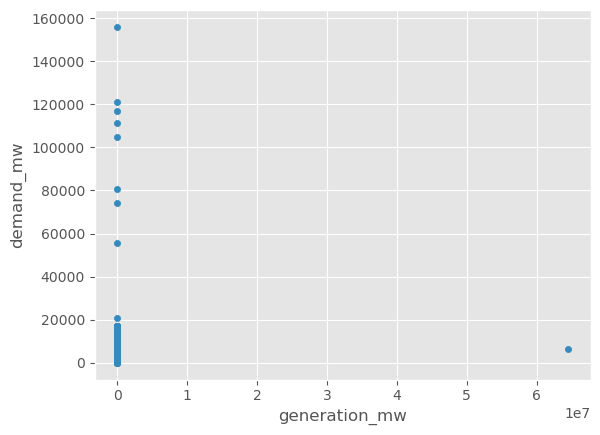

In [18]:
df_p.plot(kind='scatter', x='generation_mw', y='demand_mw')

## **Step 2.1: The Master Cleaning Function:**
Executes a centralized function (`neutralize_all_outliers`) that seamlessly handles both domain-knowledge and statistical outliers in a strict, safe order:

* **Domain Knowledge (Load Shedding):** First, it identifies physically impossible `load_shedding spikes` (e.g., > 4000 MW). If load shedding is broken, the entire hour is deemed corrupt, so it blanks out `generation_mw`, `demand_mw`, and `load_shedding` simultaneously for those rows.

* **Statistical Limits (IQR Method):** Next, it calculates the Interquartile Range (IQR) with a 3.0 multiplier to find mathematically impossible spikes specifically in the remaining `generation_mw` and `demand_mw` data, neutralizing those specific floating dots to `NaN`.

In [19]:
def neutralize_all_outliers(df, iqr_columns, multiplier=3.0, load_shedding_threshold=4000):
    df_clean = df.copy()
    
    impossible_shedding = df_clean['load_shedding'] > load_shedding_threshold
    num_poisoned = impossible_shedding.sum()
    print(f"load_shedding: Found and neutralized {num_poisoned} impossible spikes (> {load_shedding_threshold} MW).")
    
    df_clean.loc[impossible_shedding, ['generation_mw', 'demand_mw', 'load_shedding']] = np.nan

    for col in iqr_columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - (multiplier * IQR)
        upper_bound = Q3 + (multiplier * IQR)
        
        outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = outliers.sum()
        
        print(f"{col}: Found and neutralized {num_outliers} extreme statistical outliers.")
        
        df_clean.loc[outliers, col] = np.nan
        
    return df_clean

cols_to_clean = ['generation_mw', 'demand_mw'] 
df_hourly = neutralize_all_outliers(df_hourly, iqr_columns=cols_to_clean, multiplier=3.0)

print("\nTotal missing values ready for interpolation:")
print(df_hourly[['generation_mw', 'demand_mw', 'load_shedding']].isna().sum())

load_shedding: Found and neutralized 20 impossible spikes (> 4000 MW).
generation_mw: Found and neutralized 1 extreme statistical outliers.
demand_mw: Found and neutralized 5 extreme statistical outliers.

Total missing values ready for interpolation:
generation_mw    1072
demand_mw        1076
load_shedding    1071
dtype: int64


<Axes: xlabel='generation_mw', ylabel='demand_mw'>

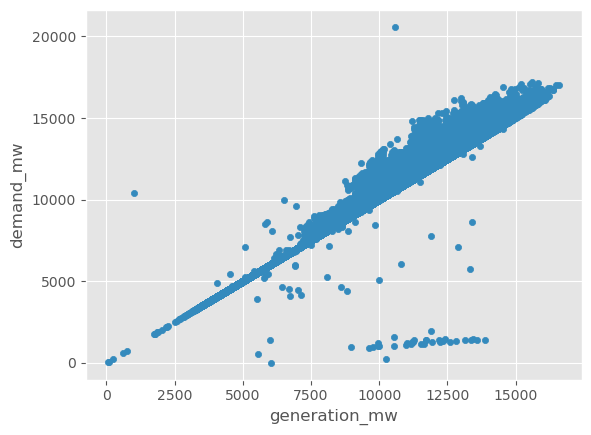

In [20]:
df_hourly.plot(kind='scatter', x='generation_mw', y='demand_mw')

## **Step 2.2:** Bivariate Outlier Neutralization (Grid Physics Cross-Validation):
Calculates an `expected_demand` metric by adding `generation_mw` + `load_shedding`. It then applies a 5% dynamic tolerance—any hour where the actual `demand_mw` deviates from this expected physical reality by more than 5% is flagged as a bivariate outlier (a floating dot disconnected from the rest of the grid physics) and neutralized to `NaN`.

In [21]:
df_hourly['expected_demand'] = df_hourly['generation_mw'] + df_hourly['load_shedding'].fillna(0)
df_hourly['grid_imbalance'] = abs(df_hourly['demand_mw'] - df_hourly['expected_demand'])

print("=== BEFORE NEUTRALIZATION ===")
print(df_hourly['grid_imbalance'].describe())


df_hourly['imbalance_pct'] = np.where(
    df_hourly['expected_demand'] > 0, 
    (df_hourly['grid_imbalance'] / df_hourly['expected_demand']) * 100, 
    0
)

tolerance_pct = 5.0
print(f"\n--- THRESHOLD ---")
print(f"Dynamic Tolerance: {tolerance_pct}% of Expected Demand")

bivariate_outliers = df_hourly['imbalance_pct'] > tolerance_pct
print(f"Neutralizing {bivariate_outliers.sum()} hours that violate grid physics...\n")

df_hourly.loc[bivariate_outliers, ['generation_mw', 'demand_mw']] = np.nan

df_hourly['expected_demand'] = df_hourly['generation_mw'] + df_hourly['load_shedding'].fillna(0)
df_hourly['grid_imbalance'] = abs(df_hourly['demand_mw'] - df_hourly['expected_demand'])

print("=== AFTER NEUTRALIZATION ===")
print(df_hourly['grid_imbalance'].describe())

df_hourly.drop(columns=['expected_demand', 'grid_imbalance', 'imbalance_pct'], inplace=True)

=== BEFORE NEUTRALIZATION ===
count    88024.000000
mean        10.556476
std        227.307326
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max      12917.000000
Name: grid_imbalance, dtype: float64

--- THRESHOLD ---
Dynamic Tolerance: 5.0% of Expected Demand
Neutralizing 89 hours that violate grid physics...

=== AFTER NEUTRALIZATION ===
count    87935.000000
mean         4.952208
std         19.632989
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max        575.000000
Name: grid_imbalance, dtype: float64


<Axes: xlabel='generation_mw', ylabel='demand_mw'>

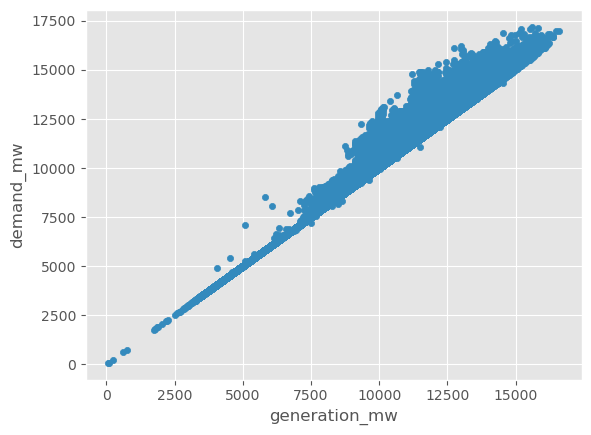

In [22]:
df_hourly.plot(kind='scatter', x='generation_mw', y='demand_mw')

# Phase 3: Strategic Missing Value Imputation

## Step 3.1: Gap Measurement:
Groups missing data into sequential blocks to classify them as "micro gaps", "medium gaps", or "black holes".

In [23]:
target_col = 'demand_mw'
is_missing = df_hourly[target_col].isna()

gap_id = (is_missing != is_missing.shift()).cumsum()
gap_blocks = is_missing[is_missing].groupby(gap_id[is_missing]).count()

print("GRID DATA RELIABILITY REPORT")
print("-" * 40)

total_hours = len(df_hourly)
total_missing = is_missing.sum()
reliability = ((total_hours - total_missing) / total_hours) * 100

print(f"Total Dataset Duration: {total_hours} hours")
print(f"Total Missing/Invalid:  {total_missing} hours")
print(f"Overall Data Health:    {reliability:.2f}%")

if not gap_blocks.empty:
    print(f"\nLargest Continuous Gap: {gap_blocks.max()} hours ({gap_blocks.max()/24:.1f} days)")
    print(f"Number of Unique Gaps:  {len(gap_blocks)}")
    
    print("\nGap Size Distribution (Top 20):")
    print("Gap Size (Hrs) | Frequency")
    print("-" * 27)
    
    dist = gap_blocks.value_counts().sort_index()
    for size, count in dist.head(20).items():
        print(f"{int(size):>13} | {count}")
else:
    print("\nNo missing gaps found.")

if not gap_blocks.empty:
    print("\nTop 10 Largest Gaps")
    top_gaps = gap_blocks.sort_values(ascending=False).head(10)
    for i, size in enumerate(top_gaps):
        gap_id_val = top_gaps.index[i]
        start_time = df_hourly[gap_id == gap_id_val].index.min()
        print(f"Gap {i+1}: {size} hours starting at {start_time}")

GRID DATA RELIABILITY REPORT
----------------------------------------
Total Dataset Duration: 89101 hours
Total Missing/Invalid:  1165 hours
Overall Data Health:    98.69%

Largest Continuous Gap: 517 hours (21.5 days)
Number of Unique Gaps:  334

Gap Size Distribution (Top 20):
Gap Size (Hrs) | Frequency
---------------------------
            1 | 285
            2 | 13
            3 | 2
            4 | 1
            5 | 1
            6 | 4
            7 | 4
            8 | 4
            9 | 4
           10 | 4
           11 | 4
           12 | 3
           14 | 1
           18 | 1
           24 | 1
           26 | 1
          517 | 1

Top 10 Largest Gaps
Gap 1: 517 hours starting at 2017-01-18 11:00:00
Gap 2: 26 hours starting at 2017-12-15 20:00:00
Gap 3: 24 hours starting at 2015-04-25 21:00:00
Gap 4: 18 hours starting at 2017-05-04 06:00:00
Gap 5: 14 hours starting at 2017-04-01 07:00:00
Gap 6: 12 hours starting at 2017-12-17 19:00:00
Gap 7: 12 hours starting at 2017-05-23 12:00:0

## Step 3.2: Dual-Strategy Imputation (Interpolation & Seasonal Imputation):
Executes a combined repair approach in a single pass. It strictly applies linear interpolation to micro gaps (<=6hrs) to smoothly connect short, localized outages. Simultaneously, for medium gaps (>6hrs and <=336hrs), it applies a "blended history" approach (averaging the exact hour from 1 week ago and 2 weeks ago) to fill the data while perfectly respecting human weekly behavioral cycles. It leaves "black hole" gaps of size 14 days or more (>336hrs) as it is, since it may be dangerous for the AI model to train on such long durations of guessed data. Not disturbing the continuous timeline, the "black hole" gaps of 'NaN' values are left to the AI model to handle implicitly.

In [24]:
df_clean = df_hourly[['generation_mw', 'demand_mw', 'load_shedding']].copy()

target_columns = ['generation_mw', 'demand_mw', 'load_shedding']

for col in target_columns:
    
    is_missing = df_clean[col].isna()
    block_ids = (is_missing != is_missing.shift()).cumsum()
    gap_sizes = is_missing.groupby(block_ids).transform('sum')

    micro_gaps = is_missing & (gap_sizes <= 6)
    medium_gaps = is_missing & (gap_sizes > 6) & (gap_sizes <= 336)
    
    full_linear = df_clean[col].interpolate(method='linear')
    df_clean.loc[micro_gaps, col] = full_linear[micro_gaps]

    hist_1_week = df_clean[col].shift(168)
    hist_2_weeks = df_clean[col].shift(336)
    
    blended_history = ((hist_1_week + hist_2_weeks) / 2).fillna(hist_1_week)
    
    df_clean.loc[medium_gaps, col] = df_clean.loc[medium_gaps, col].fillna(blended_history)

print("AUDITING REMAINING MISSING DATA\n")
is_missing_final = df_clean['demand_mw'].isna()
gap_id_final = (is_missing_final != is_missing_final.shift()).cumsum()
remaining_gaps = is_missing_final[is_missing_final].groupby(gap_id_final[is_missing_final]).count()

for idx, size in remaining_gaps.items():
    start_time = df_clean[gap_id_final == idx].index.min()
    print(f"Gap Size: {size:>3} hours | Started at: {start_time}")

print("-" * 60)
print(f"Total Remaining NaNs: {remaining_gaps.sum()} hours")

AUDITING REMAINING MISSING DATA

Gap Size:   9 hours | Started at: 2015-04-20 22:00:00
Gap Size:   3 hours | Started at: 2015-04-25 21:00:00
Gap Size: 517 hours | Started at: 2017-01-18 11:00:00
------------------------------------------------------------
Total Remaining NaNs: 529 hours


## Step 3.3: Residual Gap Polish (Secondary Interpolation): 
Addresses the small, stubborn gaps (<= 10 hours) that survived Step 3.2. These residual gaps remained because the historical data used for the "blended history" imputation occasionally contained its own missing values (e.g., if the grid was also down exactly one or two weeks prior) or due to the edge cases at the start/end of dataset. A final, targeted pass of linear interpolation safely closes these remaining secondary gaps without poisoning the massive "black hole" periods.

In [25]:
print("Applying surgical polish to historical shadows...")

for col in ['generation_mw', 'demand_mw', 'load_shedding']:
    is_missing = df_clean[col].isna()
    block_ids = (is_missing != is_missing.shift()).cumsum()
    gap_sizes = is_missing.groupby(block_ids).transform('sum')

    shadow_gaps = is_missing & (gap_sizes <= 10)
    
    full_linear = df_clean[col].interpolate(method='linear')
    df_clean.loc[shadow_gaps, col] = full_linear[shadow_gaps]

print("\nFinal NaN Count:")
print(df_clean[['generation_mw', 'demand_mw', 'load_shedding']].isna().sum())

Applying surgical polish to historical shadows...

Final NaN Count:
generation_mw    517
demand_mw        517
load_shedding    517
dtype: int64


 # Phase 4: Temporal & Target-Aligned Feature Engineering

## Step 4.1: Comprehensive Time Feature Augmentation:
Executes a unified feature engineering sweep to establish temporal geometry and contextual behavior. It extracts standard ordinal variables (hour, day, month, season) and introduces an `is_weekend` boolean flag. It then applies cyclical encoding (sine and cosine transformations) to the temporal loops to mathematically represent the continuous transition between cycles (e.g., ensuring the model understands the boundary transition from hour 23 to hour 0, or Sunday to Monday).

In [26]:
print("--- Extracting Time Features ---")

df_clean['hour'] = df_clean.index.hour
df_clean['day_of_week'] = df_clean.index.dayofweek
df_clean['month'] = df_clean.index.month
df_clean['year'] = df_clean.index.year

df_clean['is_weekend'] = df_clean['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

df_clean['season'] = (df_clean['month'] % 12 + 3) // 3

df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 23.0)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 23.0)

df_clean['month_sin'] = np.sin(2 * np.pi * df_clean.index.month / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean.index.month / 12)

df_clean['day_of_week_sin'] = np.sin(2 * np.pi * df_clean.index.dayofweek / 7)
df_clean['day_of_week_cos'] = np.cos(2 * np.pi * df_clean.index.dayofweek / 7)

print(df_clean[['demand_mw', 'hour', 'is_weekend', 'hour_sin', 'month', 'month_sin', 'day_of_week', 'day_of_week_sin']].head())

--- Extracting Time Features ---
                     demand_mw  hour  is_weekend  hour_sin  month  month_sin  \
datetime                                                                       
2015-04-19 00:00:00     4821.0     0           1  0.000000      4   0.866025   
2015-04-19 01:00:00     3612.0     1           1  0.269797      4   0.866025   
2015-04-19 02:00:00     3727.0     2           1  0.519584      4   0.866025   
2015-04-19 03:00:00     3632.0     3           1  0.730836      4   0.866025   
2015-04-19 04:00:00     3641.0     4           1  0.887885      4   0.866025   

                     day_of_week  day_of_week_sin  
datetime                                           
2015-04-19 00:00:00            6        -0.781831  
2015-04-19 01:00:00            6        -0.781831  
2015-04-19 02:00:00            6        -0.781831  
2015-04-19 03:00:00            6        -0.781831  
2015-04-19 04:00:00            6        -0.781831  


## Step 4.2: Target Alignment & Momentum Engineering:
Constructs the supervised learning target (`target_next_hour_demand`) by negatively shifting the `demand_mw` series by one step. It then generates localized momentum indicators using rolling means (6-hour and 24-hour windows) alongside temporal anchor lags (e.g., the previous hour, `shift(23)` for yesterday's target hour, and `shift(167)` for last week's target hour) to provide the model with essential historical grid context.

In [27]:
df_clean = df_clean.sort_index()

df_clean['target_next_hour_demand'] = df_clean['demand_mw'].shift(-1)

df_clean['lag_previous_hour'] = df_clean['demand_mw'].shift(1)

df_clean['lag_yesterday_target_hour'] = df_clean['demand_mw'].shift(23)

df_clean['lag_lastweek_target_hour'] = df_clean['demand_mw'].shift(167)

df_clean['rolling_mean_6h'] = df_clean['demand_mw'].rolling(window=6).mean()
df_clean['rolling_mean_24h'] = df_clean['demand_mw'].rolling(window=24).mean()

print("Target-Aligned Features Successfully Generated")

Target-Aligned Features Successfully Generated


# Phase 5: Weather Data Processing

## Step 5.1: Standardization: 
Normalizes the weather dataset's nomenclature for machine readability, mapping raw sensor labels to standardized formats (e.g., `apparent_temperature`, `precipitation_mm`, `cloud_cover_pct`).

In [28]:
print('Renaming columns')

if 'time' in df_w.columns:
    df_w.columns = ['time', 
                    'temperature_2m', 'relative_humidity_2m',
           'apparent_temperature', 'precipitation_mm', 'dew_point_2m',
           'soil_temperature_7cm', 'wind_direction',
           'cloud_cover_pct', 'sunshine_duration_s']
    
    df_w['time'] = pd.to_datetime(df_w['time'])
    df_w = df_w.set_index('time')

print('Done')
print(df_w.describe())

Renaming columns
Done
       temperature_2m  relative_humidity_2m  apparent_temperature  \
count   107304.000000         107304.000000         107304.000000   
mean        25.457445             76.806233             28.804437   
std          5.033014             16.454697              6.905288   
min          8.400000             15.000000              6.600000   
25%         22.600000             67.000000             24.200000   
50%         26.500000             81.000000             30.800000   
75%         28.800000             90.000000             33.700000   
max         40.800000            100.000000             45.600000   

       precipitation_mm   dew_point_2m  soil_temperature_7cm  wind_direction  \
count     107304.000000  107304.000000         107304.000000   107304.000000   
mean           0.205420      20.633153             26.769709      195.691260   
std            0.895574       5.231144              4.908599       94.451905   
min            0.000000       2.5000

In [29]:
df_w.isna().sum()

temperature_2m          0
relative_humidity_2m    0
apparent_temperature    0
precipitation_mm        0
dew_point_2m            0
soil_temperature_7cm    0
wind_direction          0
cloud_cover_pct         0
sunshine_duration_s     0
dtype: int64

## Step 5.2: Resampling & Auditing: 
Enforces a strict 1-hour temporal frequency on the weather data to perfectly align with the grid dataset. A physical boundary audit is then performed to verify sensor integrity, ensuring no meteorologically impossible values exist (e.g., discarding temperature readings outside the valid -5°C to 55°C range).

In [30]:
print("--- Auditing Weather Timeline Integrity ---")

df_w = df_w.resample('h').mean()

if 'time' in df_w.columns:
    df_w['time'] = pd.to_datetime(df_w['time'])
    test_index = df_w.set_index('time').index
else:
    test_index = df_w.index

perfect_timeline = pd.date_range(
    start=test_index.min(), 
    end=test_index.max(), 
    freq='h'
)

missing_timestamps = perfect_timeline.difference(test_index)

if len(missing_timestamps) == 0:
    print("Zero missing rows. The timeline is continuous.")
else:
    print(f"Found {len(missing_timestamps)} invisible missing hours!")
    print("Here is where the sensors went dark:")
    print(missing_timestamps[:10]) 

--- Auditing Weather Timeline Integrity ---
Zero missing rows. The timeline is continuous.


## Subsetting essential variables using domain knowledge

In [31]:
df_w_clean = df_w[['apparent_temperature', 'precipitation_mm', 'cloud_cover_pct']]

In [32]:
print("--- Auditing Weather Data for Physical Violations ---")

temp_violations = (df_w_clean['apparent_temperature'] < -5) | (df_w_clean['apparent_temperature'] > 55)
rain_violations = (df_w_clean['precipitation_mm'] < 0) | (df_w_clean['precipitation_mm'] > 150)
cloud_violations = (df_w_clean['cloud_cover_pct'] < 0) | (df_w_clean['cloud_cover_pct'] > 100)

print(f"Temperature sensor failures: {temp_violations.sum()}")
print(f"Precipitation sensor failures: {rain_violations.sum()}")
print(f"Cloud Cover sensor failures: {cloud_violations.sum()}")

if temp_violations.sum() > 0:
    print("\n⚠️ Sneak peek at broken Temperature rows:")
    print(df_w_clean[temp_violations].head())

--- Auditing Weather Data for Physical Violations ---
Temperature sensor failures: 0
Precipitation sensor failures: 0
Cloud Cover sensor failures: 0


# Phase 6: Macroeconomic Data Structuring (Leakage Prevention)

In [33]:
df_eco.dtypes

Country Name       object
Indicator Name     object
Indicator Code     object
1960              float64
1961              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
2025              float64
Length: 69, dtype: object

## Step 6.1: Comprehensive Macroeconomic Transformation: 
Executes a unified data pipeline to prepare the yearly economic drivers. First, it isolates the primary structural features (GDP, Manufacturing Value Added, Access to Electricity, Transmission Losses, and Population) and transforms them from a wide matrix to a time-series long format using melt and pivot. Crucially, it then applies strict look-ahead bias prevention by explicitly shifting the datetime index forward by exactly one year (ensuring, for example, that 2014's economic data only becomes accessible to the model on 2015-01-01). Finally, it bridges publication lags by applying a forward-fill (ffill) operation to carry the last known good data across the unpublished 2023 and 2024 periods.

In [34]:
print("--- Structuring Macro Indicators ---")

my_chosen_indicators = [
    'Population, total', 
    'GDP (constant 2015 US$)', 
    'Manufacturing, value added (constant 2015 US$)',
]

years_to_keep = [str(year) for year in range(2014, 2025)]

available_years = [y for y in years_to_keep if y in df_eco.columns]
cols_to_keep = ['Indicator Name'] + available_years

df_eco_sub = df_eco[df_eco['Indicator Name'].isin(my_chosen_indicators)][cols_to_keep].copy()

df_eco_long = df_eco_sub.melt(
    id_vars=['Indicator Name'], 
    var_name='Year', 
    value_name='Value'
)

df_eco_clean = df_eco_long.pivot(
    index='Year', 
    columns='Indicator Name', 
    values='Value'
)

df_eco_clean.index = pd.to_datetime(df_eco_clean.index, format='%Y') + pd.DateOffset(years=1)

df_eco_clean.columns = [
    'gdp_constant_2015_usd', 
    'manufacturing_constant_2015_usd', 
    'population_total'
]
df_eco_clean.index.name = 'time'

df_eco_clean = df_eco_clean.ffill()

print("\nMacro dataset successfully pivoted and formatted")

print(df_eco_clean)

--- Structuring Macro Indicators ---

Macro dataset successfully pivoted and formatted
            gdp_constant_2015_usd  manufacturing_constant_2015_usd  \
time                                                                 
2015-01-01           1.831460e+11                     2.970026e+10   
2016-01-01           1.951470e+11                     3.276253e+10   
2017-01-01           2.090280e+11                     3.659273e+10   
2018-01-01           2.228040e+11                     3.918586e+10   
2019-01-01           2.391120e+11                     4.328173e+10   
2020-01-01           2.579580e+11                     4.862032e+10   
2021-01-01           2.668530e+11                     4.943753e+10   
2022-01-01           2.853690e+11                     5.516494e+10   
2023-01-01           3.056300e+11                     6.145972e+10   
2024-01-01           3.232800e+11                     6.692606e+10   
2025-01-01           3.369330e+11                     6.903862e+10   

  

# Phase 7: Master Assembly

## Step 7.1: Grid & Weather Integration: 
Performs an inner join on the datetime index to fuse the hourly grid dataset with the weather dataset, ensuring only hours containing complete physical and environmental records are retained.

In [35]:
print("--- The Grid + Weather Merge ---")

start_time = df_clean.index.min()
end_time = df_clean.index.max()

print(f"Aligning timelines from {start_time} to {end_time}...")

df_w_trimmed = df_w_clean.loc[start_time:end_time]

df_combined = pd.merge(
    df_clean, 
    df_w_trimmed, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

print("\nGrid and Weather successfully merged")
print(f"Combined Dataset Shape: {df_combined.shape}")
print("-" * 60)
print(df_combined.head(3))

--- The Grid + Weather Merge ---
Aligning timelines from 2015-04-19 00:00:00 to 2025-06-17 12:00:00...

Grid and Weather successfully merged
Combined Dataset Shape: (89101, 24)
------------------------------------------------------------
                     generation_mw  demand_mw  load_shedding  hour  \
datetime                                                             
2015-04-19 00:00:00         4821.0     4821.0            0.0     0   
2015-04-19 01:00:00         3612.0     3612.0            0.0     1   
2015-04-19 02:00:00         3727.0     3727.0            0.0     2   

                     day_of_week  month  year  is_weekend  season  hour_sin  \
datetime                                                                      
2015-04-19 00:00:00            6      4  2015           1       2  0.000000   
2015-04-19 01:00:00            6      4  2015           1       2  0.269797   
2015-04-19 02:00:00            6      4  2015           1       2  0.519584   

               

## Step 7.2: Point-in-Time Macro Merge (`merge_asof`):
Integrates the macroeconomic features onto the hourly timeline utilizing Pandas' `merge_asof` algorithm. Setting the direction to `backward` acts as a strict time-series safeguard, mathematically guaranteeing that each hourly row only joins with the most recently published macroeconomic data relative to its exact timestamp, resulting in a strictly leak-proof dataset.

In [36]:
print("--- The Final Merge ---")

df_combined = df_combined.sort_index()
df_eco_clean = df_eco_clean.sort_index()

df_master = pd.merge_asof(
    df_combined,
    df_eco_clean,
    left_index=True,
    right_index=True,
    direction='backward'
)

print("\nMASTER DATASET COMPLETE")
print(f"Final Shape: {df_master.shape}")

--- The Final Merge ---

MASTER DATASET COMPLETE
Final Shape: (89101, 27)


In [37]:
# Explicitly naming index again to prevent errors in reading during model ingestion
df_master.index.name = 'datetime'

## Step 7.3: Final Export:
Serializes the fully engineered, 27-column master dataset to `Final_dataset.csv` for model ingestion.

In [39]:
df_master.to_csv('./Dataset/Final_dataset.csv')